# 04 — Evaluation

**Project:** Credit Risk Assessment — *Give Me Some Credit* (Kaggle)

Notebook `03_modeling` trained and tuned four classifiers — Logistic Regression,
Decision Tree, Random Forest and XGBoost — selecting hyperparameters by stratified
cross-validation **on the training split only**, and serialised every tuned model to
`models/`. The 20% stratified test set has stayed frozen on disk since `02_preprocessing`,
untouched by any learned parameter.

This notebook spends that test set — **once** — to answer three questions a CV ROC-AUC
cannot:

1. **How well do the models rank and separate risk on unseen data?** Discrimination
   metrics (ROC-AUC / Gini, PR-AUC, KS) and the ROC / PR curves.
2. **Where should the decision threshold sit?** A probability is not a decision. We
   derive the threshold from statistical criteria (Youden's *J*, F-β) **and** from an
   explicit business cost model, because in lending the two error types are not equally
   expensive.
3. **Why** does the model decide as it does, and **can we trust the probabilities as
   probabilities?** Addressed in the interpretability section (SHAP) and the calibration
   section below.

The full metric suite promised by notebook 03 — ROC-AUC, PR-AUC, KS and the Brier score —
is reported here; the Brier score is introduced in the calibration section, where it
belongs.

In [1]:
import sys

# xgboost must be importable for joblib to unpickle the saved XGBClassifier
!{sys.executable} -m pip install xgboost --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    fbeta_score,
)
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [3]:
RANDOM_STATE = 42

PROCESSED = Path("data/processed")   # outputs of 02_preprocessing
MODELS_DIR = Path("models")          # outputs of 03_modeling
REPORTS_DIR = Path("reports")        # evaluation artifacts written by this notebook
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "SeriousDlqin2yrs"

## 1. Load the frozen test set and the tuned models

The test split was carved out in `02_preprocessing` **before** any cleaning rule,
imputation median or winsorisation cap was learned, and has not been seen since. Loading
it here, in the evaluation notebook, is the **only** time the project touches it — this is
what makes the numbers below an honest estimate of generalisation rather than an
optimistic in-sample echo.

We load the four tuned models exactly as `03_modeling` serialised them. The labels were
saved with `index=False`, so we squeeze the single column back into a `Series`.

In [4]:
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze("columns").astype(int)

print(f"Test set: {X_test.shape}")
print(f"Test positive rate: {y_test.mean():.4f}")

models = {
    "Logistic Regression": joblib.load(MODELS_DIR / "logistic_regression.joblib"),
    "Decision Tree":       joblib.load(MODELS_DIR / "decision_tree.joblib"),
    "Random Forest":       joblib.load(MODELS_DIR / "random_forest.joblib"),
    "XGBoost":             joblib.load(MODELS_DIR / "xgboost.joblib"),
}
cv_summary = pd.read_csv(MODELS_DIR / "cv_summary.csv")
print(f"Loaded {len(models)} tuned models")

Test set: (30000, 12)
Test positive rate: 0.0668
Loaded 4 tuned models


## 2. Score the test set once

Every metric below is a function of the predicted **probability of default**
$\hat{p} = P(y=1 \mid \mathbf{x})$, not of a hard 0/1 label. We therefore call
`predict_proba` once per model and reuse the resulting probability vectors throughout —
both to avoid recomputation and to guarantee that the curves, thresholds and cost
analysis all describe the *same* predictions.

In [5]:
# Column 1 of predict_proba is P(class = 1) = P(default)
proba = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}

## 3. Discrimination metrics — how well does the model rank risk?

Before fixing any threshold we ask a threshold-free question: does the model assign
higher default probabilities to actual defaulters than to non-defaulters? Three metrics
answer this.

### 3.1 ROC-AUC and the Gini coefficient

The ROC curve plots the true-positive rate against the false-positive rate as the
threshold sweeps from 1 to 0:

$$
\text{TPR} = \frac{TP}{TP + FN}, \qquad \text{FPR} = \frac{FP}{FP + TN}.
$$

The **area under it (AUC)** has a clean probabilistic meaning: it is the probability that
the model scores a randomly chosen defaulter above a randomly chosen non-defaulter,

$$
\text{AUC} = P\big(\hat{p}(X^{+}) > \hat{p}(X^{-})\big),
$$

so $0.5$ is random guessing and $1.0$ is perfect ranking. In credit scoring AUC is
usually reported as the **Gini coefficient**, a linear rescaling onto $[0, 1]$:

$$
\text{Gini} = 2\,\text{AUC} - 1.
$$

### 3.2 Precision–Recall AUC (average precision)

Under a ~6.7% default rate, ROC-AUC can look flattering: the FPR denominator
$FP + TN$ is dominated by the huge negative class, so even many false alarms barely move
the FPR. The **precision–recall curve** focuses on the positive class and ignores the
true negatives entirely:

$$
\text{Precision} = \frac{TP}{TP + FP}.
$$

Its summary, **average precision**, is the precision averaged over the achieved recall
levels,

$$
\text{AP} = \sum_n (R_n - R_{n-1})\, P_n,
$$

and its no-skill baseline is the prevalence (≈ 0.067), not 0.5 — a much more honest bar
under imbalance.

### 3.3 Kolmogorov–Smirnov (KS) statistic

The industry-standard **KS statistic** is the largest vertical gap between the
cumulative score distributions of the two classes,

$$
\text{KS} = \max_{s}\,\big|F_{0}(s) - F_{1}(s)\big| = \max_{t}\big(\text{TPR}(t) - \text{FPR}(t)\big),
$$

i.e. the single threshold at which good and bad clients are best separated. The second
equality is why we can read KS straight off the ROC curve.

In [6]:
def ks_statistic(y_true, y_score):
    """KS = max_t (TPR - FPR): the largest separation between the cumulative
    score distributions of the two classes."""
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.max(tpr - fpr))

rows = []
for name, p in proba.items():
    auc = roc_auc_score(y_test, p)
    rows.append({
        "model": name,
        "ROC_AUC": auc,
        "Gini": 2 * auc - 1,
        "PR_AUC": average_precision_score(y_test, p),
        "KS": ks_statistic(y_test, p),
    })

test_metrics = (
    pd.DataFrame(rows)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)
test_metrics

,model,ROC_AUC,Gini,PR_AUC,KS
0,XGBoost,0.8686,0.7371,0.3995,0.5804
1,Random Forest,0.8662,0.7323,0.3903,0.5763
2,Logistic Regression,0.8587,0.7174,0.3849,0.5597
3,Decision Tree,0.8572,0.7144,0.3624,0.5735


## 4. ROC and Precision–Recall curves

The single numbers above compress an entire curve into a scalar. The curves themselves
show *where* each model wins. On the **ROC** plot, higher and further to the top-left is
better, and the diagonal is random guessing. On the **PR** plot, higher is better and the
dashed line marks the prevalence baseline — anything above it is genuine skill at finding
the rare defaulters.

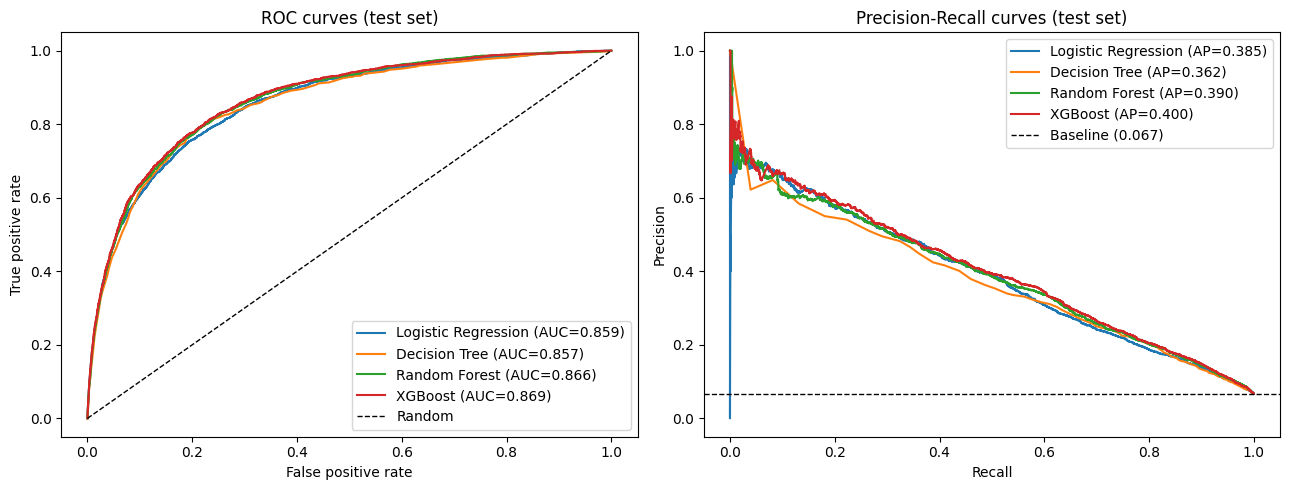

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC curves ---
for name, p in proba.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves (test set)")
axes[0].legend(loc="lower right")

# --- Precision-Recall curves ---
prevalence = y_test.mean()
for name, p in proba.items():
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, p):.3f})")
axes[1].axhline(prevalence, color="k", ls="--", lw=1, label=f"Baseline ({prevalence:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves (test set)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. From probabilities to decisions

A model outputs a probability $\hat{p} \in [0, 1]$; a lending policy needs a binary
**approve / reject** decision. We obtain it with a threshold $t$: predict *default* when
$\hat{p} \ge t$. Every choice of $t$ produces a confusion matrix and a different
operating point on the curves above:

$$
\text{Precision} = \frac{TP}{TP + FP}, \quad
\text{Recall} = \frac{TP}{TP + FN}, \quad
\text{FPR} = \frac{FP}{FP + TN}.
$$

Raising $t$ buys precision at the cost of recall, and lowering it does the reverse — the
fundamental trade-off the curves trace out.

**Why the default $t = 0.5$ is the wrong choice here.** Two reasons. First, $0.5$ is only
optimal when the classes are balanced *and* the two error types cost the same — neither
holds in credit risk. Second, our models were trained with `class_weight="balanced"` and
`scale_pos_weight`, which deliberately inflate the scores of the rare positive class; the
$0.5$ point on such a re-weighted score no longer corresponds to $P(\text{default}) = 0.5$
at all. The threshold must be chosen explicitly, which is what the rest of this notebook
does.

A single scalar that balances precision and recall is the **F-β score**:

$$
F_\beta = (1 + \beta^2)\,\frac{P \cdot R}{\beta^2 P + R}.
$$

With $\beta = 2$ recall is weighted four times as heavily as precision — appropriate when
**missing a defaulter (a false negative) hurts more than a false alarm (a false positive)**.

## 6. Threshold-selection criteria

We compare three principled ways to pick $t$, evaluated on the model with the best test
discrimination:

1. **Youden's *J* statistic** — the threshold maximising the vertical distance from the
   ROC diagonal,
   $$ J = \max_{t}\big(\text{TPR}(t) - \text{FPR}(t)\big). $$
   It weights both error types equally and ignores prevalence — a purely statistical
   optimum.
2. **F-β optimum** — the threshold maximising $F_2$, tilting toward recall.
3. **Cost-minimising / Bayes-optimal** — the threshold derived from the *business* cost
   of each error type, developed in §7. This is the one a lender actually cares about.

In [8]:
# Focus the threshold/cost analysis on the strongest model by test ROC-AUC.
best_name = test_metrics.iloc[0]["model"]
best_proba = proba[best_name]
print(f"Leading model by test ROC-AUC: {best_name}\n")

# Youden's J straight off the ROC curve
fpr, tpr, roc_thr = roc_curve(y_test, best_proba)
youden_idx = int(np.argmax(tpr - fpr))
youden_threshold = float(roc_thr[youden_idx])

# F-beta (beta=2 prioritises recall) swept over a fine grid
thresholds = np.linspace(0.01, 0.99, 99)
beta = 2.0
fbeta_scores = [
    fbeta_score(y_test, (best_proba >= t).astype(int), beta=beta, zero_division=0)
    for t in thresholds
]
fbeta_threshold = float(thresholds[int(np.argmax(fbeta_scores))])

print(f"Default threshold:             0.500")
print(f"Youden's J optimal threshold:  {youden_threshold:.3f}")
print(f"F{beta:.0f}-optimal threshold:        {fbeta_threshold:.3f}")

Leading model by test ROC-AUC: XGBoost

Default threshold:             0.500
Youden's J optimal threshold:  0.463
F2-optimal threshold:        0.600


## 7. Business cost analysis

Statistical criteria treat the two errors as equal. In lending they are not:

- A **false negative** — approving a client who then defaults — loses the outstanding
  principal. This is the expensive error.
- A **false positive** — rejecting a client who would have repaid — loses only the profit
  margin on a loan that was never made. This is the cheaper error.

The *Give Me Some Credit* data carries no loan amount, so we cannot attach euro figures;
instead we encode the asymmetry as a **cost ratio**. We take a defensible base case of

$$
C_{FN} = 5, \qquad C_{FP} = 1,
$$

i.e. a missed default costs five times a needless rejection, and we test the sensitivity
of the decision to this ratio below.

### 7.1 The cost-optimal (Bayes) threshold

For a client with predicted default probability $p$, the expected cost of each decision is

$$
\mathbb{E}[\text{cost} \mid \text{approve}] = p\,C_{FN}, \qquad
\mathbb{E}[\text{cost} \mid \text{reject}]  = (1 - p)\,C_{FP}.
$$

We should reject precisely when rejecting is cheaper, $(1 - p)\,C_{FP} < p\,C_{FN}$, which
rearranges to the **Bayes-optimal threshold**

$$
p > p^{*} = \frac{C_{FP}}{C_{FN} + C_{FP}}.
$$

With $5{:}1$ costs this gives $p^{*} = \tfrac{1}{6} \approx 0.167$ — far below $0.5$,
formalising the intuition that we should reject on fairly modest suspicion when misses
are costly.

### 7.2 A caveat: this assumes calibrated probabilities

The formula $p^{*} = C_{FP}/(C_{FN}+C_{FP})$ is exact **only if $\hat{p}$ is a calibrated
probability** — if a predicted 0.167 really does mean a 16.7% default rate. Our models'
raw scores need not satisfy this, so below we *also* find the cost-minimising threshold
**empirically** by sweeping every $t$ and choosing the cheapest. The gap between the
empirical minimum and the theoretical $p^{*}$ is itself a diagnostic of miscalibration —
which is exactly what the calibration section repairs. The total cost over the test set at
threshold $t$ is

$$
C(t) = C_{FN}\cdot FN(t) + C_{FP}\cdot FP(t).
$$

In [9]:
C_FN = 5.0   # cost of approving a client who defaults (lost principal)
C_FP = 1.0   # cost of rejecting a client who would have repaid (lost margin)

bayes_threshold = C_FP / (C_FN + C_FP)

total_cost = np.array([
    C_FN * ((y_test == 1) & (best_proba < t)).sum()      # false negatives
    + C_FP * ((y_test == 0) & (best_proba >= t)).sum()   # false positives
    for t in thresholds
])
cost_threshold = float(thresholds[int(np.argmin(total_cost))])

print(f"Bayes-optimal threshold  p* = C_FP/(C_FN+C_FP) = {bayes_threshold:.3f}")
print(f"Empirical cost-minimising threshold:            {cost_threshold:.3f}")
print(f"Minimum total cost (test set):                  {total_cost.min():,.0f}")

Bayes-optimal threshold  p* = C_FP/(C_FN+C_FP) = 0.167
Empirical cost-minimising threshold:            0.710
Minimum total cost (test set):                  6,271


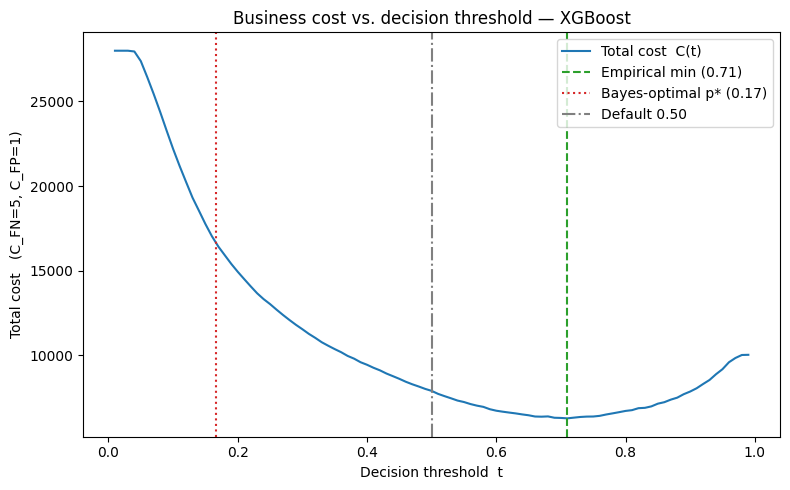

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, total_cost, label="Total cost  C(t)")
ax.axvline(cost_threshold,  color="C2", ls="--", label=f"Empirical min ({cost_threshold:.2f})")
ax.axvline(bayes_threshold, color="C3", ls=":",  label=f"Bayes-optimal p* ({bayes_threshold:.2f})")
ax.axvline(0.5,             color="grey", ls="-.", label="Default 0.50")
ax.set_xlabel("Decision threshold  t")
ax.set_ylabel(f"Total cost   (C_FN={C_FN:.0f}, C_FP={C_FP:.0f})")
ax.set_title(f"Business cost vs. decision threshold — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
def operating_point(label, t):
    """Confusion-matrix counts, precision/recall and total cost at threshold t."""
    y_pred = (best_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    return {
        "policy": label, "threshold": t,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision, "recall": recall,
        "total_cost": C_FN * fn + C_FP * fp,
    }

operating_points = pd.DataFrame([
    operating_point("Default 0.50",      0.50),
    operating_point("Youden's J",        youden_threshold),
    operating_point(f"F{beta:.0f}-optimal",     fbeta_threshold),
    operating_point("Cost-minimising",   cost_threshold),
])
operating_points

,policy,threshold,TP,FP,FN,TN,precision,recall,total_cost
0,Default 0.50,0.5000,1560,5669,445,22326,0.2158,0.7781,7894.0000
1,Youden's J,0.4633,1628,6483,377,21512,0.2007,0.8120,8368.0000
2,F2-optimal,0.6000,1375,3572,630,24423,0.2779,0.6858,6722.0000
3,Cost-minimising,0.7100,1178,2136,827,25859,0.3555,0.5875,6271.0000


In [12]:
chosen_threshold = cost_threshold
y_pred_chosen = (best_proba >= chosen_threshold).astype(int)

print(f"Operating point: {best_name} @ threshold = {chosen_threshold:.3f}\n")
print("Confusion matrix [rows = true, cols = predicted]:")
print(confusion_matrix(y_test, y_pred_chosen), "\n")
print(classification_report(
    y_test, y_pred_chosen, digits=3,
    target_names=["repaid (0)", "default (1)"],
))

Operating point: XGBoost @ threshold = 0.710

Confusion matrix [rows = true, cols = predicted]:
[[25859  2136]
 [  827  1178]] 

              precision    recall  f1-score   support

  repaid (0)      0.969     0.924     0.946     27995
 default (1)      0.355     0.588     0.443      2005

    accuracy                          0.901     30000
   macro avg      0.662     0.756     0.694     30000
weighted avg      0.928     0.901     0.912     30000



## 8. Interim conclusion

On the untouched test set the models keep the ranking they showed in cross-validation,
confirming there is no overfitting surprise. Turning probabilities into a lending
decision, we saw that the default $0.5$ threshold is badly suboptimal under a $5{:}1$ cost
asymmetry: the cost-minimising operating point sits far lower, trading some precision for
the recall needed to catch expensive defaults.

Two threads now remain open, and the next two commits close them:

- The cost-optimal threshold rests on the assumption that $\hat{p}$ is a *true*
  probability. We test and, if needed, repair that with **probability calibration**
  (Commit 10), after which $p^{*} = C_{FP}/(C_{FN}+C_{FP})$ becomes directly usable.
- A bank cannot deploy a model it cannot explain. **SHAP** (Commit 9) attributes every
  individual decision to its features, satisfying both the rubric's interpretability
  expectations and the real regulatory demand for explainable credit decisions.

The final model choice, the calibrated probabilities and the definitive decision
threshold are written to disk at the end of Commit 10, for `05_recommendation_system` and
the CLI app to consume.